# 🧠 Trabajo 1:
Regresión lineal

## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
- Versión: 1.0.0
- Licencia: MIT


🎯 **Instrucciones:**

- Al entregar la práctica, se debe entregar tanto el fichero .ipynb como un informe.pdf. En el informe pdf deben incluirse todos los elementos necesarios para valorar la práctica.
- Al puntuar, se valora positivamente contenido extra que aporte valor a la práctica, y es necesario para obtener la máxima nota posible.
- En todos los apartados lo principal es la interpretación que hace el alumno de los resultados, por ejemplo: en caso de que se pida calcular un valor, no limitarse a calcularlo, sino explicar qué significa y qué implica en el contexto de la práctica. Si no se razonan los resultados se valorará de manera reducida.
- El trabajo es grupal, todos los integrantes deben participar para obtener nota. En caso contrario, se debe contactar con el tutor a través de mensaje privado por la plataforma para resolver el problema.

**🌍 Contexto del trabajo**

En esta primera práctica vamos a aplicar los conocimientos impartidos en las clases utilizando la herramienta Google Collab para calcular regresiones como las vistas, aprovechando el potencial para representar gráficos para visualizar fácilmente los outliers.

# 🏗️ Preparación de datos para el entrenamiento:

*******************************************************************************

Utilizando los datos de entrenamiento que se muestran a continuación, genera el modelo de
regresión lineal, y representa en una gráfica los datos de entrenamiento, así como la línea
de mejor ajuste. No es necesario hacer una regresión lineal desde cero, sino que
aprovecharemos las librerías ya desarrolladas LinearRegression de
sklearn.linear_model.

## 🚀 Dataset Utilizado para el Trabajo

In [120]:
# Dataset para el ejercicio

#datos de prueba
X = [[3],[6],[8.9],[12],[15],[18],[21]]
Y = [1.2,3.0,4.1,4.7,5.9,8.2,9.5]

## 🚀 Importacion de librerias

In [121]:
########## librerías a utilizar ##########

# Se importan la librerías a utilizar

# importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression

# 1️⃣ Fase 1: Regresión Lineal Básica


Importamos las librerias que vamos a usar para realizar el uso del algoritmo de Regresión Lineal

## 🚀 1.1 Entrenamiento y Predicción de modelo mediante Regresión Lineal


In [122]:
# Realizaremos la regresión lineal en base a los datos de prueba

# Seleccionamos el modelo
model = LinearRegression()

# Entranamos el modelo
model.fit(X,Y)

# Generamos una prediccion en base al entrenamiento
X_line = np.array([[20]]).reshape(-1,1) ## Lo colocamos en 2D
Y_pred = model.predict(X_line)

# Mostraremos una predicción
print("Prediccion resultante con 20: ", Y_pred)

# Mostraremos las variables m y b
print("Valor de m: ", model.coef_[0])
print("Valor de b: ", model.intercept_)


Prediccion resultante con 20:  [8.76326728]
Valor de m:  0.4410493931887845
Valor de b:  -0.05772058407700342


## 🚀 1.2 Previsualizacion y validacion mediante Regresión Lineal

📥 Visualizaremos la regresión lineal obtenida:

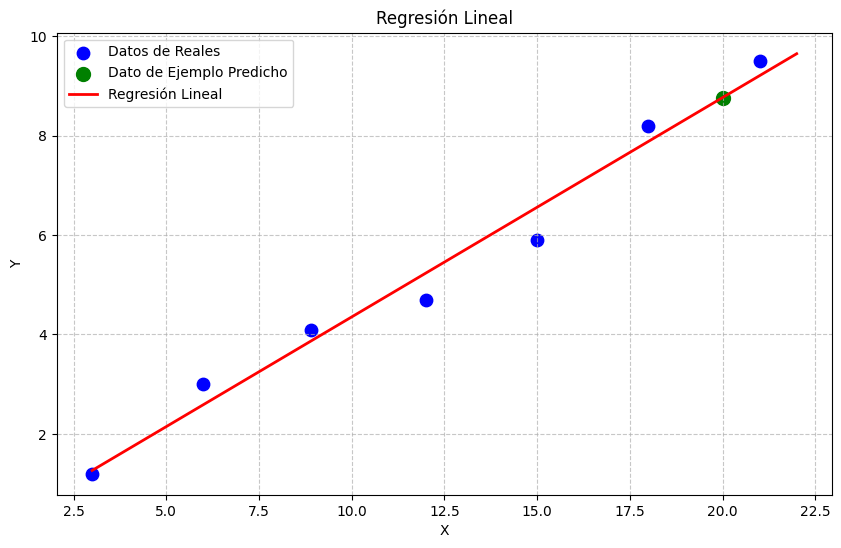

In [123]:

# Creamos un rango desde X=3 hasta X=22 para cubrir tu predicción  (ESTO ES LA LINEA)
X_linea = np.linspace(3, 22, 100).reshape(-1, 1)
Y_linea = model.predict(X_linea)

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X, Y, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_line, Y_pred, color='green', label='Dato de Ejemplo Predicho', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()


### 🧠 Interpretación

Luego de realizar el entrenamiento con la regresión lineal obtuvimos una predicción de 8.76326728 con una variable de 20. Según el entrenamiento se obtuvo que la variable m(Pendiente) se tiene de 0.4410493931887845 y que la b(Intersección) es -0.05772058407700342. En base a eso realizamos el calculo mediante la formula (y = mx + b) tenemos:

**y=(0.4410493931887845 * 20)+( -0.05772058407700342)**



Entonce y= 8.76326728, es un número que esta dentro de la linea de la regresión como muestra el gráfico que se realizó.



## 🚀 1.3 Comparación contra el algoritmo de árbol de decisión

Dentro del algoritmo aritmetico de regresión lineal tenemos una linea donde los valores que más se acerquen a dicha linea son predecibles dentro de un modelo. Por otro lado, con los mismos datos vamos a realizar un árbol de decisión que clasificará los datos para obtener una predicción basada en ramas y hojas.

In [124]:
# Importación de libreria
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Creamos el modelo en base al mismo conjunto de datos

model_tree = DecisionTreeRegressor(max_depth=5, random_state=42) # Agregamos los hiperparametros de una profundidad de 5 y la semilla

# Entrenamos el modelo
model_tree.fit(X, Y)

# Realizamos la predicción
X_tree = np.array([[20]]).reshape(-1, 1)
nodo_leaf = model_tree.apply(X_tree)[0]
Y_pred_tree = model_tree.predict(X_tree)


# Mostramos el resultado
print("Predicción resultante con 20: ", Y_pred_tree)
# Imprimimos el nodo Id que pertenece nuestra predicción
print(f"Para el valor X={X_tree}, el modelo encontró automáticamente el Nodo #{nodo_leaf}")


Predicción resultante con 20:  [9.5]
Para el valor X=[[20]], el modelo encontró automáticamente el Nodo #12


## 🚀 1.4 Previsualizacion y validacion mediante árbol de decisión

📥 Visualizaremos el árbol de decisión obtenido:

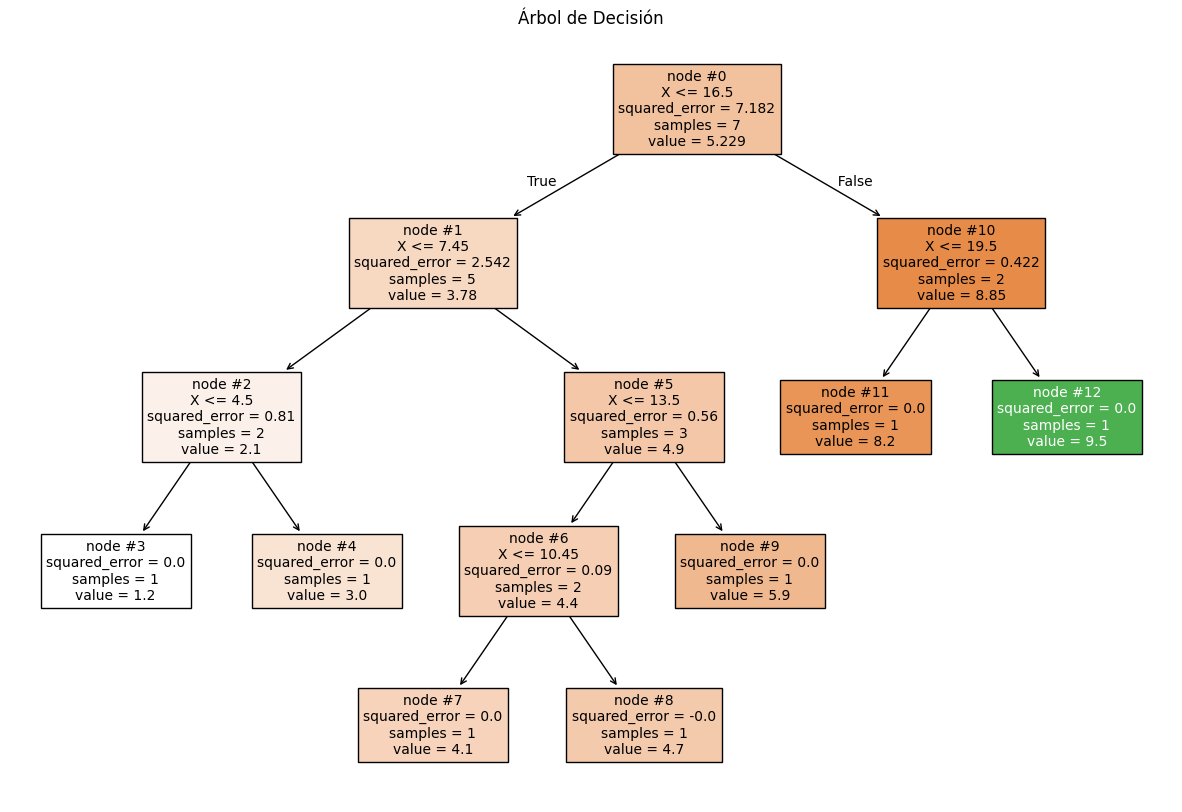

In [125]:
# Preparación de gráfico

fig, ax = plt.subplots(figsize=(15,10))
nodos = plot_tree(model_tree, filled=True, feature_names=['X'], fontsize=10, node_ids=True)

# Cambiaremos de color al nodo de nuestra predicción

nodo_obj = nodos[(nodo_leaf+2)] # Porque ponemos +2 porque matplot no almacena el nodo por cajas sino por ramas
nodo_obj.set_bbox(dict(facecolor='#4CAF50', alpha=1.0))
nodo_obj.set_color('white')

# Mostrar gráfico
plt.title('Árbol de Decisión')
plt.show()


### 🧠 Interpretación

Con el mismo conjunto de datos encontramos otra estrategia para realizar la predicción que en este caso nos dio 9.5 mucho mayor respecto al algoritmo de regresión lineal, considerando que el anterior era unas alineado a la matematica con el objetivo que este dentro del rango que se traza la linea, en este caso se clasificó los datos y se realizó 5 niveles del árbol para realizar la comparativa y como usa los minimos cuadrados para su clasificación entonces en este caso el valor cayó en el falso del árbol hasta encontrarse en el nodo 12 que notamos en el gráfico.

# 2️⃣ Fase 2: Outliers y ajuste de funciones


## 🔍 Parte A: Partiendo del código de la Fase I, vuelve a entrenar un modelo pero ahora con siguientes datos, y representa la gráfica con los puntos y línea de mejor ajuste:

In [126]:
# Datos de prueba

#datos fase II (parte A)
X = [[1],[2],[3],[4],[5],[6],[7],[20],[30],[40],[50],[60],[70],[80],[90]]
Y = [2,3,4.1,4.7,6,8,9.5,20,46,90,301,1345,6000,22000,89000]

## 🚀 2.1 Entrenamiento y Predicción de modelo mediante Regresión Lineal


In [127]:
# Realizaremos la regresión lineal en base a los datos de prueba

# Seleccionamos el modelo
model = LinearRegression()

# Entranamos el modelo
model.fit(X,Y)

# Generamos una prediccion en base al entrenamiento
X_line = np.array([[100]]).reshape(-1,1) ## Lo colocamos en 2D
Y_pred = model.predict(X_line)

# Mostraremos una predicción
print("Prediccion resultante con 100: ", Y_pred)

# Mostraremos las variables m y b
print("Valor de m: ", model.coef_[0])
print("Valor de b: ", model.intercept_)

Prediccion resultante con 100:  [40418.93865006]
Valor de m:  472.33021293692246
Valor de b:  -6814.082643631981


## 🚀 2.2 Previsualizacion y validacion mediante Regresión Lineal

📥 Visualizaremos la regresión lineal obtenida:

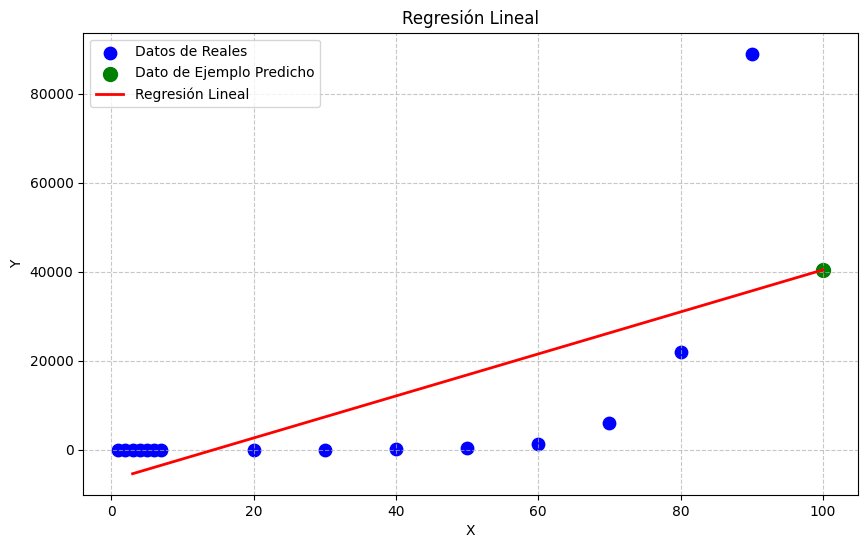

In [128]:
# Creamos un rango desde X=3 hasta X=22 para cubrir tu predicción  (ESTO ES LA LINEA)
X_linea = np.linspace(3, 100).reshape(-1, 1)
Y_linea = model.predict(X_linea)

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X, Y, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_line, Y_pred, color='green', label='Dato de Ejemplo Predicho', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()


### 🧠 2.2.1 Interpreta los resultados obtenidos, hablando de la línea de ajuste.

Revisando el gráfico notamos que existen datos fuera del rango que estan impidiendo una correcta correlación de los datos sobre todo el dato atipico en la parte superior que destruye cualquier entrenamiento de. Por lo tanto, si existen outliers. Notamos que la inclinación es menor comparando al anterior conjunto de datos pero los datos fuera de la rango esta impidiendo crear un modelo más cerca de la realidad de los datos.

### 🧠 2.2.2 ¿Hay outliers? En caso de haberlos, ¿Que se hace con ellos?

El siguiente paso es tratar el conjunto de datos para limpiar aquellos datos atipicos que tenemos. Tenemos dos opciones: realizamos una eliminación del dato que nos esta haciendo el desbalance en el conjunto de datos o lo imputamos para no perder datos para el entrenamiento.


En este caso, como es un conjunto de datos pequeño nos vamos por la estrategia de imputación del valor mediante una tranformación logaritmica debido a el tipo de datos exponeciales que tenemos en el conjunto de datos.

Debido a los datos exponenciales se veria un gráfico más cercano a una curva que haria imposible crear un modelo aceptable para este ejemplo. Por ello, se realizó la imputacíon mediante la transformación logaritmica que nos da como resultado un gráfico linealizado y predicciones coherentes.




In [129]:
# Vamos a realizar la imputación identificando un umbral en base al conjunto de datos
Y_np = np.array(Y)
Y_log = np.log1p(Y_np)

# Con estos datos podemos ver la escala de los datos de la original con respecto a la logarítmica
print("Escala original del último dato:", Y[-1])
print("Escala logarítmica del último dato:", Y_log[-1])

# Predicción con 100 para este modelo

X_line = np.array([[100]]).reshape(-1,1) ## Lo colocamos en 2D
Y_pred = model.predict(X_line)

# Entrenamos el modelo
model.fit(X, Y_log)

# Mostraremos una predicción
print("Prediccion resultante con 100: ", Y_pred)
print("Valor de m: ", model.coef_[0])
print("Valor de b: ", model.intercept_)

# Imprimimos el nuevo conjunto Y
print("Conjunto Y original:", Y)
print("Conjunto Y logarítmico:", Y_log)


Escala original del último dato: 89000
Escala logarítmica del último dato: 11.39640288460621
Prediccion resultante con 100:  [40418.93865006]
Valor de m:  0.10627001713110425
Valor de b:  1.1353687917023647
Conjunto Y original: [2, 3, 4.1, 4.7, 6, 8, 9.5, 20, 46, 90, 301, 1345, 6000, 22000, 89000]
Conjunto Y logarítmico: [ 1.09861229  1.38629436  1.62924054  1.74046617  1.94591015  2.19722458
  2.35137526  3.04452244  3.8501476   4.51085951  5.71042702  7.20489251
  8.6996814   9.99884319 11.39640288]


#### 🚀 Previsualización y validación del modelo limpio de outliers


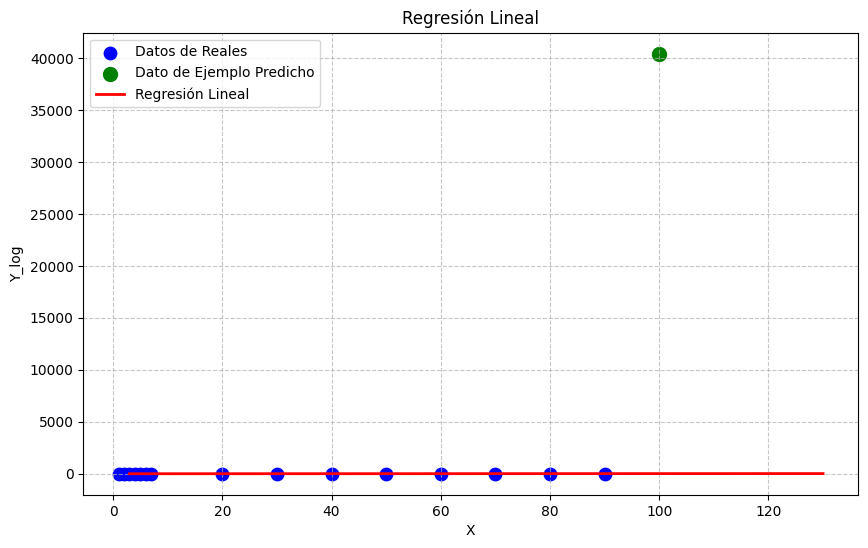

In [130]:
# Creamos un rango desde X=3 hasta X=100 para cubrir tu predicción  (ESTO ES LA LINEA)
X_linea = np.linspace(3, 130).reshape(-1, 1)
Y_linea = model.predict(X_linea)

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X, Y_log, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_line, Y_pred, color='green', label='Dato de Ejemplo Predicho', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y_log')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()

### 🧠 2.2.3 Utiliza el modelo obtenido para realizar una predicción para los valores X=17 y X=110 y comenta los resultados.


Ya tenemos un modelo entrenado con el conjunto de datos mediante la imputación de transformación logaritmica que nos permitirá tener predicciones más acertadas.


En la predicción se nota que el valor de 110 se alinea correctamente en la linea trazado por el modelo y se realiza una predicción correcta. Sin embargo, el 17 se convirtio en un valor atipico dentro del modelo debido al método de tranformación logaritmica y como esta soportando valores exponenciales pero con valores menores se vuelven valores atipicos.

In [131]:
# Creamos un rango desde X=17 hasta X=110 para cubrir tu predicción
X_17 = np.array([[17]]).reshape(-1, 1)
Y_17 = model.predict(X_17)

X_110 = np.array([[110]]).reshape(-1, 1)
Y_110 = model.predict(X_110)

# Mostraremos una predicción
print("Prediccion resultante con 17: ", Y_17)
print("Prediccion resultante con 110: ", Y_110)

Prediccion resultante con 17:  [2.94195908]
Prediccion resultante con 110:  [12.82507068]


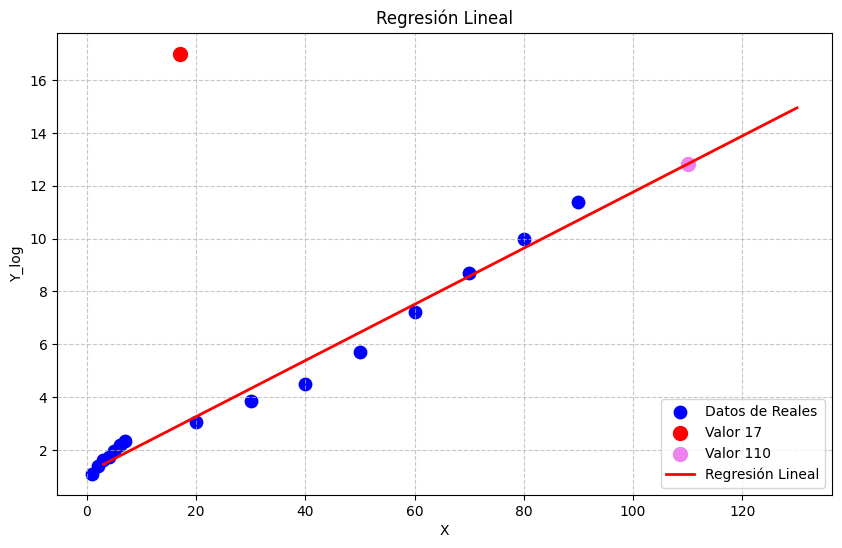

In [132]:

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X, Y_log, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_17, X_17, color='red', label='Valor 17', s=100)
plt.scatter(X_110, Y_110, color='violet', label='Valor 110', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y_log')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()

## 🔍 Parte B: Vuelve a hacerlo con los siguientes datos:

In [133]:
# Datos de prueba

#datos fase II (parte B)
X = [[10],[20],[30],[40],[50],[60],[70],[80],[90],[100],[50]]
Y = [2,3,4.1,4.7,6,8,9.5,12,16,20,26]

## 🚀 2.3 Entrenamiento y Predicción de modelo mediante Regresión Lineal


In [136]:
# Realizaremos la regresión lineal en base a los datos de prueba

# Seleccionamos el modelo
model = LinearRegression()

# Entranamos el modelo
model.fit(X,Y)

# Generamos una prediccion en base al entrenamiento
X_line = np.array([[55]]).reshape(-1,1) ## Lo colocamos en 2D
Y_pred = model.predict(X_line)

# Mostraremos una predicción
print("Prediccion resultante con 55: ", Y_pred)

# Mostraremos las variables m y b
print("Valor de m: ", model.coef_[0])
print("Valor de b: ", model.intercept_)

Prediccion resultante con 55:  [10.19868132]
Valor de m:  0.17709890109890108
Valor de b:  0.4582417582417584


## 🚀 2.2 Previsualizacion y validacion mediante Regresión Lineal

📥 Visualizaremos la regresión lineal obtenida:

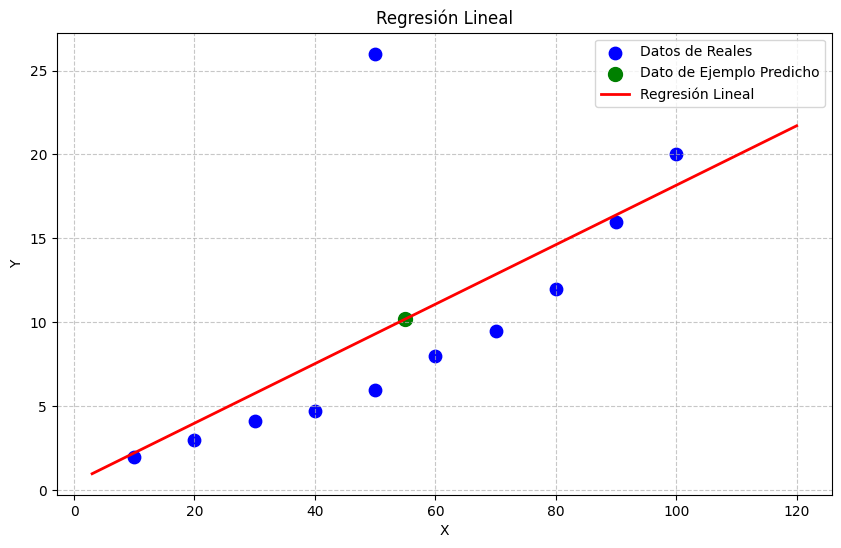

In [138]:
# Creamos un rango desde X=3 hasta X=22 para cubrir tu predicción  (ESTO ES LA LINEA)
X_linea = np.linspace(3, 120).reshape(-1, 1)
Y_linea = model.predict(X_linea)

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X, Y, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_line, Y_pred, color='green', label='Dato de Ejemplo Predicho', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()


### 🧠 2.4.1 Interpreta los resultados obtenidos, hablando de la línea de ajuste.

En este gráfico, tenemos datos más cercanos a la linea de regresión que se plantea de acuerdo al ejemplo del grupo A. En este caso tendriamos que hacer la limpieza similar al ejemplo B. Se interpreta también que tenemos un solo outlier pero sigue marcando una tendencia curvilinea los datos que no marca una linea recta perfecta.

### 🧠 2.4.2 ¿Hay outliers? En caso de haberlos, ¿Que se hace con ellos?

Como lo hicimos en el ejemplo A, pasamos es tratar el conjunto de datos para limpiar aquellos datos atipicos que tenemos con la misma opción que realizamos anteriormente que es transformación logaritmica.


In [139]:
# Vamos a realizar la imputación identificando un umbral en base al conjunto de datos
Y_np = np.array(Y)
Y_log = np.log1p(Y_np)

# Con estos datos podemos ver la escala de los datos de la original con respecto a la logarítmica
print("Escala original del último dato:", Y[-1])
print("Escala logarítmica del último dato:", Y_log[-1])

# Predicción con 55 para este modelo

X_line = np.array([[55]]).reshape(-1,1) ## Lo colocamos en 2D
Y_pred = model.predict(X_line)

# Entrenamos el modelo
model.fit(X, Y_log)

# Mostraremos una predicción
print("Prediccion resultante con 55: ", Y_pred)
print("Valor de m: ", model.coef_[0])
print("Valor de b: ", model.intercept_)

# Imprimimos el nuevo conjunto Y
print("Conjunto Y original:", Y)
print("Conjunto Y logarítmico:", Y_log)


Escala original del último dato: 26
Escala logarítmica del último dato: 3.295836866004329
Prediccion resultante con 55:  [10.19868132]
Valor de m:  0.020125260971024836
Valor de b:  1.0920444336858546
Conjunto Y original: [2, 3, 4.1, 4.7, 6, 8, 9.5, 12, 16, 20, 26]
Conjunto Y logarítmico: [1.09861229 1.38629436 1.62924054 1.74046617 1.94591015 2.19722458
 2.35137526 2.56494936 2.83321334 3.04452244 3.29583687]


#### 🚀 Previsualización y validación del modelo limpio de outliers


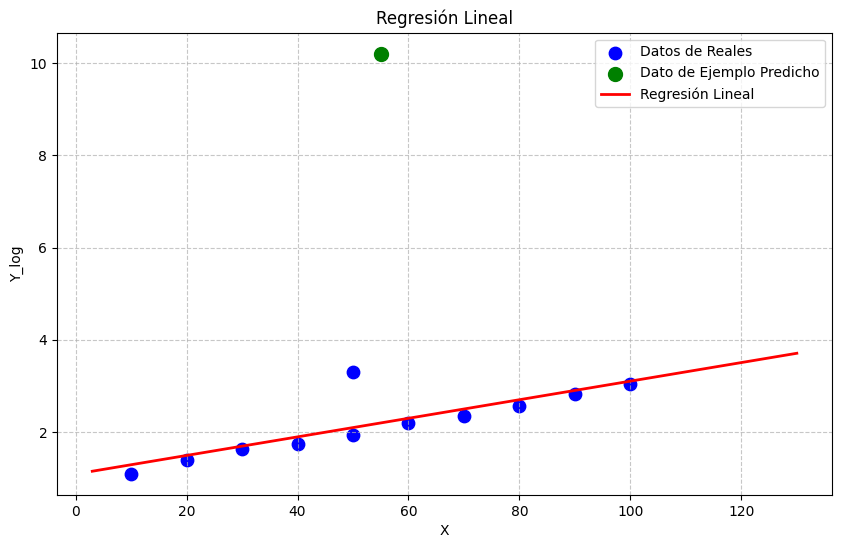

In [140]:
# Creamos un rango desde X=3 hasta X=100 para cubrir tu predicción  (ESTO ES LA LINEA)
X_linea = np.linspace(3, 130).reshape(-1, 1)
Y_linea = model.predict(X_linea)

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X, Y_log, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_line, Y_pred, color='green', label='Dato de Ejemplo Predicho', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y_log')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()

### 🧠 2.4.3 Utiliza el modelo obtenido para realizar una predicción para los valores X=5 y X=120 y comenta los resultados.


Luego de entrenar el modelo con los datos del ejemplo B, encontramos que los datos con valor menores a 50 tienden a volverse outliers por la transformación logaritmica y hace que el modelo no pueda predecir con montos pequeños.

Se puede mitigar este error usando estrategias de estandarización de escalado que tiene la libreria de sklearn que es StandardScaler.

In [141]:
# Creamos un rango desde X=5 hasta X=120 para cubrir tu predicción
X_5 = np.array([[17]]).reshape(-1, 1)
Y_5 = model.predict(X_5)

X_120 = np.array([[110]]).reshape(-1, 1)
Y_120 = model.predict(X_110)

# Mostraremos una predicción
print("Prediccion resultante con 17: ", Y_5)
print("Prediccion resultante con 110: ", Y_120)

Prediccion resultante con 17:  [1.43417387]
Prediccion resultante con 110:  [3.30582314]


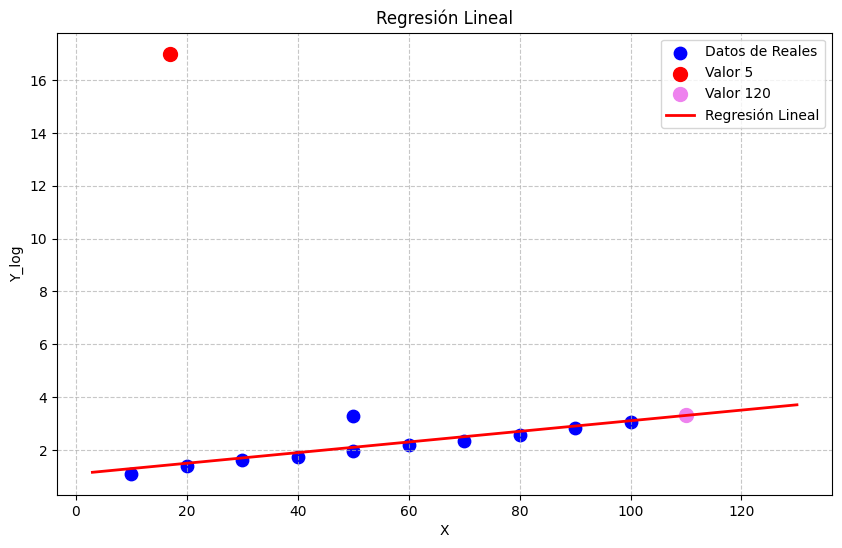

In [143]:

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X, Y_log, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_5, X_5, color='red', label='Valor 5', s=100)
plt.scatter(X_120, Y_120, color='violet', label='Valor 120', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y_log')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()

# 3️⃣ Fase 3: Regresión lineal, set de entrenamiento y R²

Partiendo del código de la Fase II, cambia la serie de datos por una generada
aleatoriamente usando el siguiente código. Atención a la variable semilla, deberás
inicializarla con la inicial del nombre de un integrante del grupo:

In [149]:
#Generar datos de ejemplo

sed = ord('C') # cada grupo debe cambiarlo por una inicial
np.random.seed(sed)
X = 2 * np.random.rand(100, 1)
m = np.random.uniform(-1, 1)
Y = m*4 + 3 * X + np.random.randn(100, 1)

# Imprimimos los conjunto de datos

print("Conjunto X:", X.tolist())
print("Conjunto Y:", Y.tolist())

Conjunto X: [[1.0917028598699572], [1.717713221182718], [1.3717851731331583], [0.6631836420268684], [0.11999585912123578], [0.7725555620854179], [0.4262997173687113], [1.8650133001627203], [1.4456365977117243], [0.0937906133367592], [1.6426216987689957], [1.1837389985817235], [0.5041430167784791], [0.6301533807796211], [0.37567604451829517], [0.7006398140941184], [0.5144856237884623], [0.02222823064650381], [0.8191770197368944], [0.8245089030519352], [0.08637754179286405], [1.9100175868574447], [0.795354569546991], [1.0593167792875327], [0.46562582532303276], [0.6172099050242199], [1.1039556784535085], [1.4169512580174872], [1.9068491063951534], [1.2038496145038804], [0.8045031398928404], [0.7098603990787102], [1.628326980611695], [0.5952837183611437], [1.0892286499143806], [1.926164432062751], [0.3667909509302414], [1.4559946765058067], [1.4664801297482257], [0.09227995711785231], [1.9391727875458793], [0.7410870864012207], [1.4138884750428669], [0.5478614031966584], [0.49809012971108

## 🚀 3.1 Entrenamiento y Predicción de modelo mediante Regresión Lineal


In [157]:
# Realizaremos la regresión lineal en base a los datos de prueba

# Seleccionamos el modelo
model = LinearRegression()

# Entranamos el modelo
model.fit(X,Y)

# Generamos una prediccion en base al entrenamiento
X_line = np.array([[3]]).reshape(-1,1) ## Lo colocamos en 2D
Y_pred = model.predict(X_line)

# Mostraremos una predicción
print("Prediccion resultante con 100: ", Y_pred)

# Mostraremos las variables m y b
print("Valor de m: ", model.coef_[0])
print("Valor de b: ", model.intercept_)

Prediccion resultante con 100:  [[10.50273725]]
Valor de m:  [2.9318171]
Valor de b:  [1.70728595]


## 🚀 3.2 Previsualizacion y validacion mediante Regresión Lineal

📥 Visualizaremos la regresión lineal obtenida:

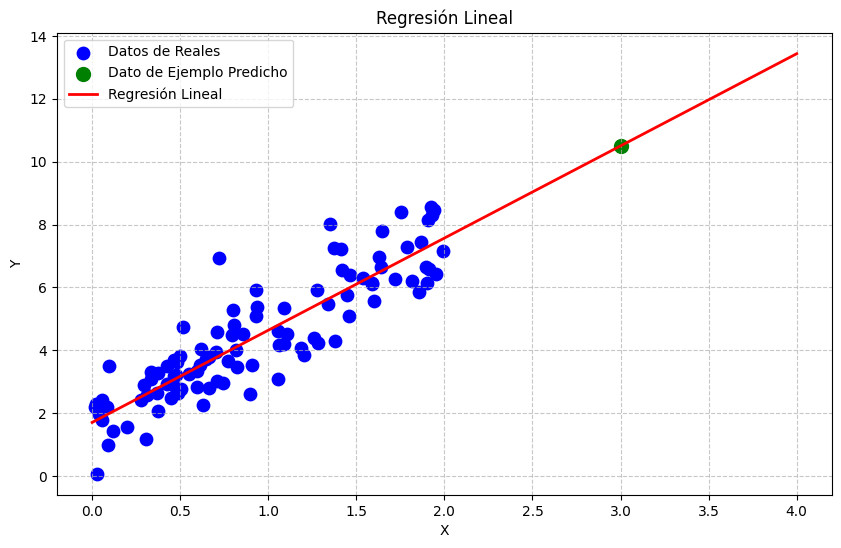

In [162]:
# Creamos un rango desde X=0.0000001 hasta X=3.99999 para cubrir tu predicción  (ESTO ES LA LINEA)
X_linea = np.linspace(0.0000001, 3.99999).reshape(-1, 1)
Y_linea = model.predict(X_linea)

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X, Y, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_line, Y_pred, color='green', label='Dato de Ejemplo Predicho', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()

## 🚀 3.3 ¿Qué podemos concluir en base a lo aplicado anteriormente?


En este caso, tenemos la información demasiado robusta en la parte inferior y eso necesita la división que se pide en el ejercicio. A continuación, vamos a realizar dicha configuración para mejorar el modelo.


In [169]:
from sklearn.model_selection import train_test_split  # <- Para dividir datos
from sklearn.metrics import r2_score                  # <- Para medir R²


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) # Realizamos la división 80% para entrenamiento y 20% para test


print(f"Total de datos originales: {len(X)}")
print(f"Datos asignados a Entrenamiento: {len(X_train)}")
print(f"Datos ocultos para la Prueba: {len(X_test)}\n")

Total de datos originales: 100
Datos asignados a Entrenamiento: 80
Datos ocultos para la Prueba: 20



In [170]:
# Entrenamos nuevamente el modelo

model = LinearRegression()
model.fit(X_train, Y_train)

# Evaluamos los datos mediante la metrica de lo R2
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

r2_train = r2_score(Y_train, y_pred_train)
r2_test = r2_score(Y_test, y_pred_test)

print(f"R² para el conjunto de entrenamiento: {r2_train:.4f} ({r2_train*100:.1f}%)")
print(f"R² para el conjunto de prueba: {r2_test:.4f} ({r2_test*100:.1f}%)")

R² para el conjunto de entrenamiento: 0.8054 (80.5%)
R² para el conjunto de prueba: 0.6256 (62.6%)


## 🚀 3.4 Previsualizacion y validacion con la división del conjunto de datos

📥 Visualizaremos la regresión lineal obtenida:

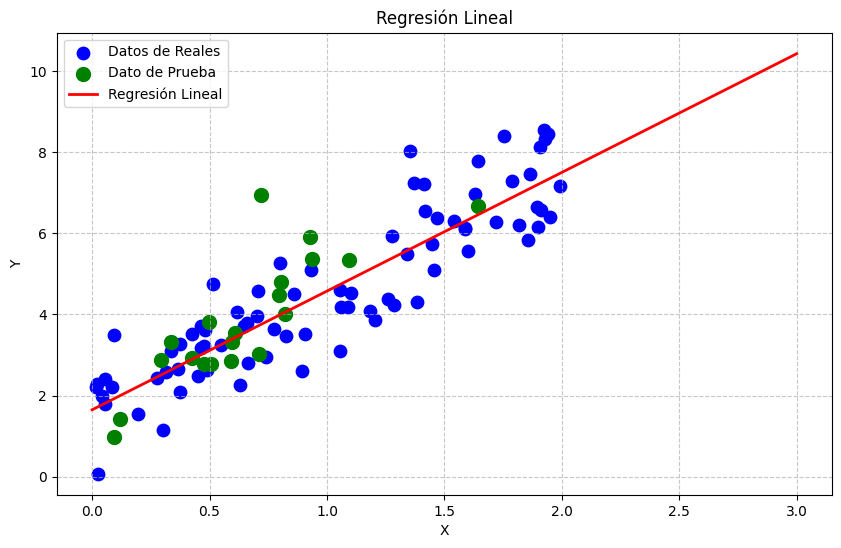

In [179]:
# Creamos un rango desde X=0.0000001 hasta X=3.99999 para cubrir tu predicción  (ESTO ES LA LINEA)
X_linea = np.linspace(0.0000001, 2.99999).reshape(-1, 1)
Y_linea = model.predict(X_linea)

# Creamos el gráfico

plt.figure(figsize=(10,6))
plt.scatter(X_train, Y_train, color='blue', label='Datos de Reales', s=80)
plt.scatter(X_test, Y_test, color='green', label='Dato de Prueba', s=100)
plt.plot(X_linea, Y_linea, color='red', linewidth=2, label='Regresión Lineal')

# Personalización

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión Lineal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()

## 🧠 Interpretación

El gráfico revela que la caída del rendimiento en el conjunto de prueba se debe a la distribución azarosa de los puntos verdes (Test) y a un sutil desajuste de forma. Al hacer la división aleatoria, la suerte provocó que algunos puntos de prueba quedaran llamativamente alejados de la línea de regresión —destacando un punto verde rebelde muy alto cerca de X=0.7 y un par de puntos muy bajos cerca de X=0.1—, lo cual penaliza severamente el score R^{2} debido a que los errores se elevan al cuadrado. Además, si observas la masa de puntos azules (Train), estos describen una ligera curvatura ascendente que se despega de la recta roja a partir de X=1.3, demostrando que una línea recta es demasiado rígida para capturar a la perfección la verdadera naturaleza de tus datos.

📌 Diagnóstico Final

Para el conjunto de datos que hemos realizado el entrenamiento de los datos concluimos que tenemos un overfitting moderado en nuestro modelo entonces se necesita ampliar el conjunto de datos o cambiar el algoritmo para la predicción. Tenemos 20% en el conjunto de datos que nos hace falta para tener un modelo predictor correcto para este ejemplo

# 🚀 Aplicación en Entorno Laboral
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **ROMEL MICHAEL CERNA PACHECO**
El proyecto Titanic puede aplicarse en el entorno bancario para predecir fallos en procesos batch, clasificar incidentes y monitorear ETLs mediante modelos de Machine Learning como Regresión Logística y K-NN. A partir del preprocesamiento, análisis exploratorio y optimización de variables, es posible identificar patrones operacionales, detectar anomalías y anticipar problemas críticos antes de que ocurran, mejorando la gestión de soporte, la automatización y la toma de decisiones preventivas en ambientes productivos.


# 🖥️ **CARRERA DIAZ CHRISTIAN JAVIER**
El análisis de datos y las técnicas de Machine Learning permiten identificar patrones relevantes para mejorar la toma de decisiones en entornos reales. En un entorno laboral, estos procesos pueden aplicarse para detectar anomalías, optimizar reportes, automatizar análisis y generar información más precisa para apoyar decisiones estratégicas basadas en datos.